## 折线图

### 延迟

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# 创建画布和子图
fig, ax = plt.subplots()

# 使用Seaborn样式
sns.set(style="whitegrid")

# 绘制折线图
ax.plot(119.2, 71.4, label='BEVFusion', marker='o' ) 
# ax.plot(156.6, 71.3, label='TransFusion', marker='*' ) 
ax.plot(96, 70.8, label='CMT', marker='h' ) 
# ax.plot(1000/5.5, 74, label='MV2DFusion', marker='h' ) 
ax.plot(34.4, 61.3, label='PointPillars', marker='x') 
ax.plot(80, 66.8, label='CenterPoint', marker='d') 
ax.plot(1000/31.7, 54, label='StreamPERT', marker='v') 
ax.plot([1000/21.5, 1000/23], [68.2, 67.7], label='HeightFusion', marker='s', color='red')

# 添加标签和标题
ax.set_xlabel('延迟(毫秒)')
ax.set_ylabel('NDS')
# ax.set_title( 'The relationship between NDS and delay of various methods') 
ax.legend() # 添加图例

# 显示图形
plt.savefig('latency.pdf')
plt.show()

In [2]:
from matplotlib import pyplot as plt
import matplotlib
a=sorted([f.name for f in matplotlib.font_manager.fontManager.ttflist])

for i in a:
    print(i)

AR PL UKai CN
AR PL UMing CN
Abyssinica SIL
Ani
AnjaliOldLipi
C059
C059
C059
C059
Chandas
Chilanka
D050000L
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif Display
Droid Sans Fallback
Dyuthi
FreeMono
FreeMono
FreeMono
FreeMono
FreeSans
FreeSans
FreeSans
FreeSans
FreeSerif
FreeSerif
FreeSerif
FreeSerif
Gargi
Garuda
Garuda
Garuda
Garuda
Gayathri
Gayathri
Gayathri
Gubbi
Jamrul
KacstArt
KacstBook
KacstDecorative
KacstDigital
KacstFarsi
KacstLetter
KacstNaskh
KacstOffice
KacstOne
KacstOne
KacstPen
KacstPoster
KacstQurn
KacstScreen
KacstTitle
KacstTitleL
Kalapi
Kalimati
Karumbi
Keraleeyam
Khmer OS
Khmer OS System
Kinnari
Kinnari
Kinnari
Kinnari
Kinnari
Kinnari
LKLUG
Laksaman
Laksaman
Laksaman
Laksaman
Liberation Mono
Liberation Mono
Liberation Mono
Liberation

### 帧率

In [ ]:
# 创建画布和子图
fig, ax = plt.subplots()

# 使用Seaborn样式
sns.set(style="whitegrid")

# 绘制折线图
ax.plot(1000/119.2, 71.4, label='BEVFusion', marker='o' ) 
ax.plot(1000/156.6, 71.3, label='TransFusion', marker='*' ) 
# ax.plot(5.5, 74, label='MV2DFusion', marker='h' ) 
ax.plot(1000/34.4, 61.3, label='PointPillars', marker='x') 
ax.plot(31.7, 54, label='StreamPERT', marker='v') 
ax.plot([21.5, 23], [68.2, 67.7], label='HeightMap', marker='s',color='red')

# 添加标签和标题
ax.set_xlabel('FPS')
ax.set_ylabel('NDS val')
ax.set_title( 'Line Chart') 
ax.legend() # 添加图例

# 显示图形
plt.show()

### 显存占用

In [ ]:
# 创建画布和子图
fig, ax = plt.subplots()

# 使用Seaborn样式
sns.set(style="whitegrid")

# 绘制折线图
ax.plot(119.2, 71.4, label='BEVFusion', marker='o' ) 
# ax.plot(156.6, 71.3, label='TransFusion', marker='*' ) 
ax.plot(96, 70.8, label='CMT', marker='h' ) 
# ax.plot(1000/5.5, 74, label='MV2DFusion', marker='h' ) 
ax.plot(34.4, 61.3, label='PointPillars', marker='x') 
ax.plot(1000/31.7, 54, label='StreamPERT', marker='v') 
ax.plot([1000/21.5, 1000/23], [68.2, 67.7], label='HeightMap', marker='s', color='red')

# 添加标签和标题
ax.set_xlabel('Memory(MiB)')
ax.set_ylabel('NDS')
ax.set_title( 'Line Chart') 
ax.legend() # 添加图例

# 显示图形
plt.show()

In [ ]:
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-trainval', dataroot='/datasets/nuscenes/trainval', verbose=True)

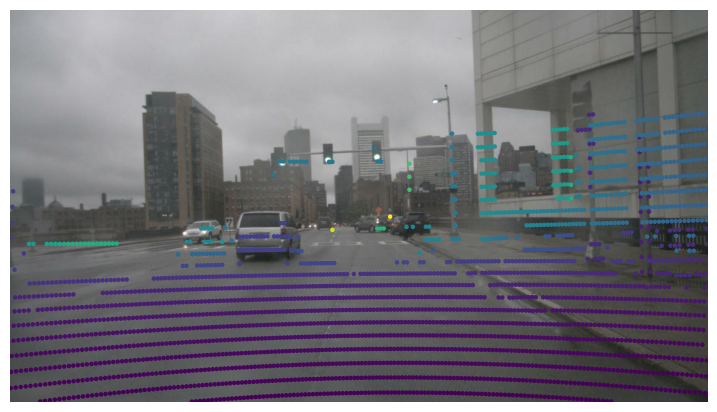

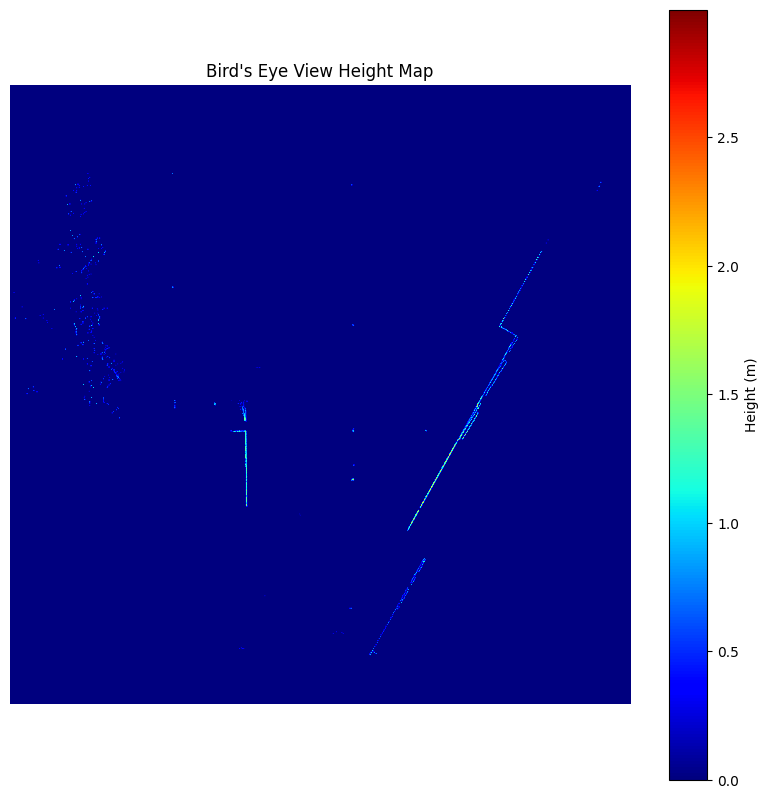

In [11]:

# 获取点云数据
# my_scene_token = nusc.field2token('scene', 'name', 'scene-0061')[0]

# 获取场景对象
scene = nusc.get('scene', "1e3f0bd8063a4084b7104345b20bfb80")


# 获取场景的第一帧
sample_token = scene['last_sample_token']
sample = nusc.get('sample', sample_token)

nusc.render_pointcloud_in_image(sample_token, pointsensor_channel='LIDAR_TOP')

# 获取激光雷达数据
lidar_token = sample['data']['LIDAR_TOP']
lidar_data_path, boxes, camera_intrinsic = nusc.get_sample_data(lidar_token)

# 加载点云数据
# points是一个 (N, 5) 的数组, 其中前3列是 x, y, z 坐标
points = np.fromfile(lidar_data_path, dtype=np.float32).reshape(-1, 5)[:, :3]

# --- 点云转高度图代码开始 ---
import torch # 确保torch已导入
import numpy as np # 确保numpy已导入
import matplotlib.pyplot as plt # 确保matplotlib.pyplot已导入

# 设置点云范围和栅格参数 (您可以根据需要调整这些值)
pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0] # [x_min, y_min, z_min, x_max, y_max, z_max]
grid_size = 0.2  # 每个栅格的物理尺寸（米）

# 计算BEV图尺寸
x_min, y_min, z_min, x_max, y_max, z_max = pc_range
H = int((y_max - y_min) / grid_size)
W = int((x_max - x_min) / grid_size)

# 将点云转换为torch tensor
points_tensor = torch.from_numpy(points)

# 创建高度图 (初始化为最小值，或者一个特定的背景值)
# 我们这里用z_min作为背景高度，之后会填充实际点云的最大高度
height_map = torch.full((H, W), float(z_min), dtype=torch.float32) # 使用z_min初始化

# 过滤在定义范围内的点
mask_x = (points_tensor[:, 0] >= x_min) & (points_tensor[:, 0] < x_max)
mask_y = (points_tensor[:, 1] >= y_min) & (points_tensor[:, 1] < y_max)
mask_z = (points_tensor[:, 2] >= z_min) & (points_tensor[:, 2] < z_max)
valid_mask = mask_x & mask_y & mask_z
points_filtered = points_tensor[valid_mask]

if points_filtered.shape[0] > 0:
    # 将点云坐标转换为栅格索引
    # 注意：这里y轴可能需要反转，取决于您希望的图像坐标系
    # matplotlib imshow的(0,0)在左上角
    pts_x_grid = ((points_filtered[:, 0] - x_min) / grid_size).long()
    pts_y_grid = ((points_filtered[:, 1] - y_min) / grid_size).long()
    # 或者 pts_y_grid = (H - 1 - ((points_filtered[:, 1] - y_min) / grid_size)).long() # 如果需要y轴反转

    # 确保索引在有效范围内 (虽然大部分已通过pc_range过滤，但边界情况需要注意)
    pts_x_grid = torch.clamp(pts_x_grid, 0, W - 1)
    pts_y_grid = torch.clamp(pts_y_grid, 0, H - 1)

    # 对于每个栅格单元，找到最高点的Z值
    # 这是一种高效的方法，避免显式循环每个栅格
    # 我们将高度值组织起来，然后使用scatter_max_
    # 注意：scatter_max_ 需要一维索引
    indices = pts_y_grid * W + pts_x_grid
    
    # 创建一个临时的高度图用于scatter_max_操作，并用一个非常小的值初始化
    # 这样可以确保即使栅格中只有一个点，其高度也能被正确记录
    temp_height_values = torch.full((H * W,), float('-inf'), dtype=torch.float32)
    temp_height_values.scatter_reduce_(0, indices, points_filtered[:, 2], reduce="amax", include_self=False) # include_self=False for newer PyTorch, or use scatter_max_ for older
    
    # 将计算出的最大高度值放回2D高度图
    # 处理那些没有点云的栅格(它们仍然是float('-inf'))
    valid_heights_mask = temp_height_values > float('-inf')
    height_map_flat = height_map.flatten()
    height_map_flat[valid_heights_mask] = temp_height_values[valid_heights_mask]
    height_map = height_map_flat.reshape(H, W)


# --- 点云转高度图代码结束 ---

# 可视化高度图
plt.figure(figsize=(12, 12))
# 如果之前用z_min初始化，并且希望没有点的地方是白色或特定颜色，可以在imshow前处理
# 例如，将z_min的值替换为np.nan使其不显示，或者根据cmap调整
plot_height_map = height_map.cpu().numpy() # 转换为numpy用于matplotlib
# 对于没有点云的区域（之前是z_min或者-inf），可以设置一个特定的背景色
# plot_height_map[plot_height_map == z_min] = np.nan # 使这些区域透明 (如果cmap支持)

plt.imshow(plot_height_map, cmap='jet', origin='lower', vmin=z_min, vmax=z_max) # origin='lower'使(0,0)在左下角
plt.colorbar(label='Height (m)')
plt.xlabel('X Grid Cell')
plt.ylabel('Y Grid Cell')
plt.title(f'Height Map Visualization for Sample: {sample_token}')
plt.grid(False) # 通常在图像上不显示网格
plt.show()


In [12]:
!pip install torch

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 3.1 MB/s eta 0:00:0000:0100:06
  Using cached https://mirrors.tuna.tsinghua.edu.cn/pypi/web/packages/b9/f8/feced7779d755758a52d1f6635d990b8d98dc0a29fa568bbe0625f18fdf3/filelock-3.16.1-py3-none-any.whl (16 kB)
  Using cached https://mirrors.tuna.tsinghua.edu.cn/pypi/web/packages/99/ff/c87e0622b1dadea79d2fb0b25ade9ed98954c9033722eb707053d310d4f3/sympy-1.13.3-py3-none-any.whl (6.2 MB)
  Using cached https://mirrors.tuna.tsinghua.edu.cn/pypi/web/packages/a8/05/9d4f9b78ead6b2661d6e8ea772e111fc4a9fbd866ad0c81906c11206b55e/networkx-3.1-py3-none-any.whl (2.1 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 3.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 1.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 3.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━